In [1]:
import pathlib
import collections
import random
import statistics as stats

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm


DATA_DIR = pathlib.Path(".")
LABEL_DIR = DATA_DIR / "train" / "labels"
IMAGE_DIR = DATA_DIR / "train" / "images"

# Font for rendering Deseret characters
font_path = "NotoSansDeseret-Regular.ttf"
deseret_font = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = deseret_font.get_name()
fm.fontManager.addfont(font_path)


label_files = sorted(LABEL_DIR.glob("*.txt"))
print(f"Found {len(label_files)} label files")


Found 1804 label files


## Quick EDA Checklist ##

In [ ]:
# Build character set/vocabulary
all_labels = []
char_counter = collections.Counter()

for lf in label_files:
    text = lf.read_text(encoding="utf-8").strip()
    all_labels.append(text)
    char_counter.update(text)

vocab = sorted(char_counter.keys())
print("\n=== Character Set / Vocabulary ===")
print(f"Vocab size: {len(vocab)}")
print("Characters (first 80 shown):")
print("".join(vocab[:80]))
print("\nChar frequencies (top 20):")
for ch, cnt in char_counter.most_common(20):
    printable = ch if ch != " " else "<SPACE>"
    print(f"'{printable}': {cnt}")


=== Character Set / Vocabulary ===
Vocab size: 101
Characters (first 80 shown):
 !#'(),-.0123456789:;=?IVX^¶𐐀𐐁𐐂𐐃𐐄𐐅𐐆𐐇𐐈𐐉𐐊𐐌𐐍𐐎𐐏𐐐𐐑𐐒𐐓𐐔𐐕𐐖𐐗𐐘𐐙𐐚𐐛𐐜𐐝𐐞𐐟𐐡𐐢𐐣𐐤𐐨𐐩𐐪𐐫𐐬𐐭𐐮𐐯𐐰𐐱𐐲𐐳𐐴𐐵𐐶𐐷𐐸

Char frequencies (top 20):
'<SPACE>': 15738
'𐑌': 4230
'𐐻': 3577
'𐐮': 3221
'𐑉': 3202
'𐐼': 3161
'𐐯': 2743
'𐑄': 2450
'𐐰': 2437
'𐑅': 2310
'𐐲': 2172
'𐑊': 1851
'𐑋': 1727
'𐐸': 1711
'𐐨': 1655
',': 1622
'𐑆': 1484
'𐐱': 1276
'𐐩': 1255
'𐐭': 1235



=== Sequence Lengths ===
Number of Samples: 1804
Max Length: 77
Min Length: 1
Mean Length: 41.96
Median Length: 45.0
Standard Deviation: 15.14


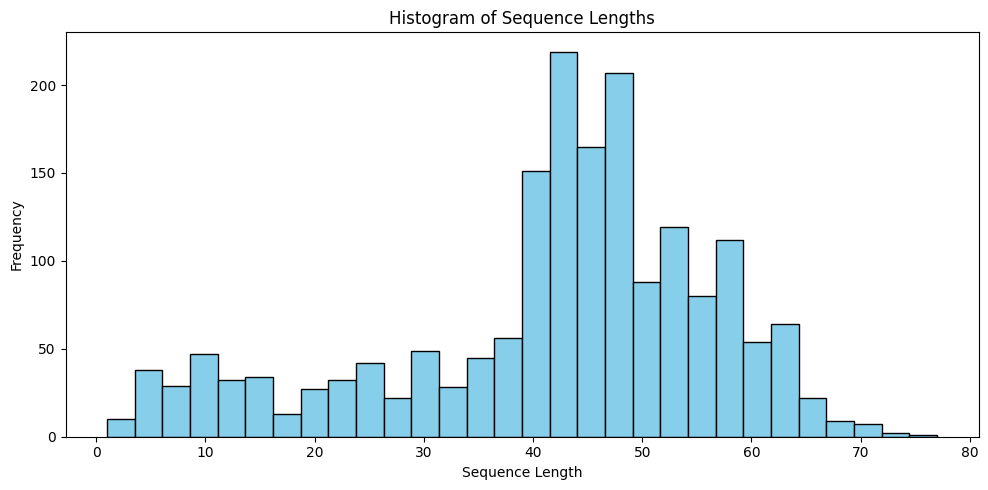

In [ ]:
# Find sequence lengths (use the label strings, not the Path objects)
lengths = [len(label) for label in all_labels]

print("\n=== Sequence Lengths ===")
print(f"Number of Samples: {len(lengths)}")
print(f"Max Length: {max(lengths)}")
print(f"Min Length: {min(lengths)}")
print(f"Mean Length: {stats.mean(lengths):.2f}")
print(f"Median Length: {stats.median(lengths)}")
print(f"Standard Deviation: {stats.stdev(lengths):.2f}")

# Histogram of sequence lengths
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=30, color="skyblue", edgecolor="black")
plt.title("Histogram of Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



=== Image Dimensions ===
Number of Images: 1804
Height - Max: 161, Min: 64, Mean: 93.01, Median: 93.0, StdDev: 8.07
Width  - Max: 1966, Min: 1944, Mean: 1955.92, Median: 1956.0, StdDev: 4.03


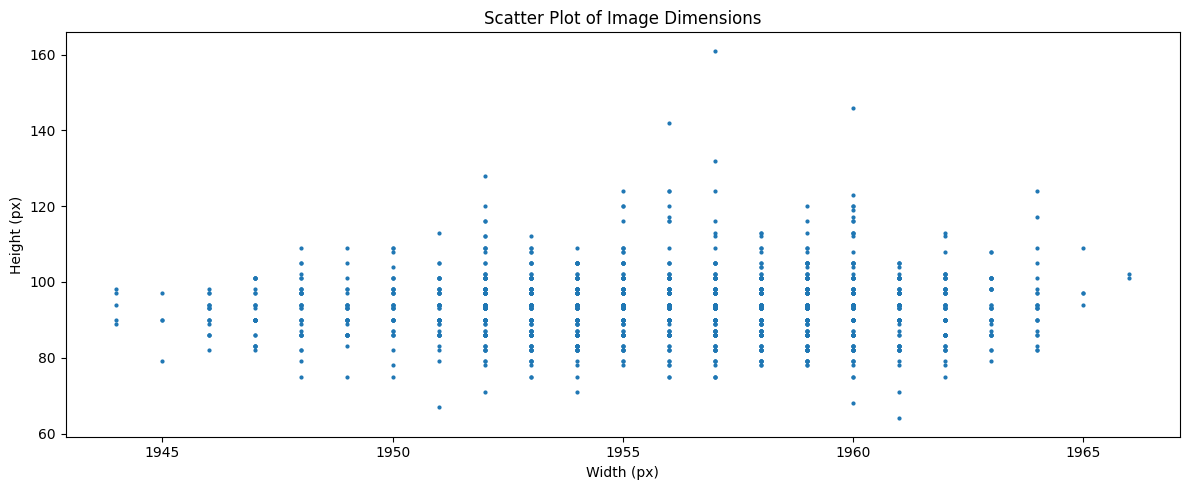

In [11]:
# Image Stats

heights = []
widths = []

image_files = sorted(IMAGE_DIR.glob("*.png"))

for img_path in image_files:
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
    
print("\n=== Image Dimensions ===")
print(f"Number of Images: {len(image_files)}")
print(f"Height - Max: {max(heights)}, Min: {min(heights)}, Mean: {stats.mean(heights):.2f}, Median: {stats.median(heights)}, StdDev: {stats.stdev(heights):.2f}")
print(f"Width  - Max: {max(widths)}, Min: {min(widths)}, Mean: {stats.mean(widths):.2f}, Median: {stats.median(widths)}, StdDev: {stats.stdev(widths):.2f}")

# Histograms of image dimensions
plt.figure(figsize=(12, 5))
plt.scatter(widths, heights, s=4)
plt.title("Scatter Plot of Image Dimensions")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.tight_layout()
plt.show()


=== 5 Random Sample Images and Labels ===


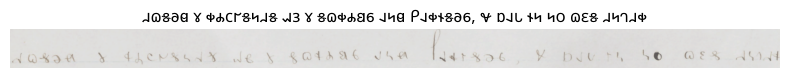

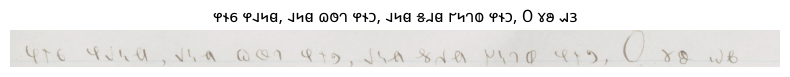

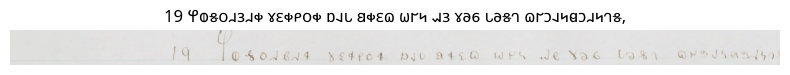

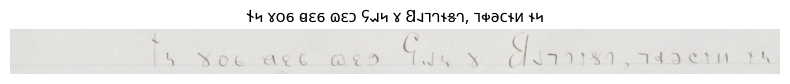

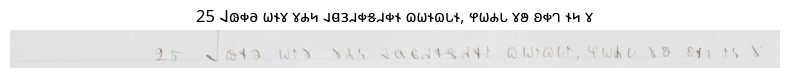

In [2]:
# Data Quality
def show_random_samples(n=5):
    print(f"\n=== {n} Random Sample Images and Labels ===")
    for _ in range(n):
        lf = random.choice(label_files)
        label = lf.read_text(encoding="utf-8").strip()
        img_id = lf.stem
        img_path = IMAGE_DIR / f"{img_id}.png"

        if not img_path.exists():
            print(f"Image file {img_path} not found for label file {lf}")
            continue

        with Image.open(img_path) as img:
            plt.figure(figsize=(8,2))
            plt.imshow(img, cmap="gray")
            plt.axis("off")
            plt.title(label)
            plt.tight_layout()
            plt.show()

show_random_samples(n=5)
# Need to change font somehow so the labels actually show up

## Modeling ##

### Config ###

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np

#======== Config ========#
DATA_DIR = pathlib.Path(".")
TRAIN_LABEL_DIR = DATA_DIR / "train" / "labels"
TRAIN_IMAGE_DIR = DATA_DIR / "train" / "images"

TARGET_HEIGHT = 96 # I think 96 is optimal based on my EDA, let's hope
DOWNSAMPLE_FACTOR = 4 # Must be power of 2 due to CNN architecture
BATCH_SIZE = 8
NUM_EPOCHS = 3 # Remember to increase later
LR = 1e-3
VAL_SPLIT = 0.1
RANDOM_SEED = 42
DEVICE = "cpu" # I dont have a GPU :(

### Vocab and Training Labels ###

In [6]:
label_files = sorted(TRAIN_LABEL_DIR.glob("*.txt"))

all_labels = []
char_counter = collections.Counter()

for lf in label_files:
    text = lf.read_text(encoding="utf-8").strip()
    all_labels.append(text)
    char_counter.update(text)

chars = sorted(char_counter.keys())

char2idx = {ch: idx + 1 for idx, ch in enumerate(chars)}  # Start indexing from 1
idx2char = {idx + 1: ch for idx, ch in enumerate(chars)}

VOCAB_SIZE = len(chars) + 1  # +1 for the CTC blank token

print(f"Vocab size (including blank): {VOCAB_SIZE}")
print("Characters (first 80 shown):", "".join(chars[:80]))

Vocab size (including blank): 102
Characters (first 80 shown):  !#'(),-.0123456789:;=?IVX^¶𐐀𐐁𐐂𐐃𐐄𐐅𐐆𐐇𐐈𐐉𐐊𐐌𐐍𐐎𐐏𐐐𐐑𐐒𐐓𐐔𐐕𐐖𐐗𐐘𐐙𐐚𐐛𐐜𐐝𐐞𐐟𐐡𐐢𐐣𐐤𐐨𐐩𐐪𐐫𐐬𐐭𐐮𐐯𐐰𐐱𐐲𐐳𐐴𐐵𐐶𐐷𐐸


### Data and Image Preprocessing ###

In [10]:
def load_and_preprocess_image(path: pathlib.Path, target_height: int = TARGET_HEIGHT):
    # Load image
    # Convert to grayscale
    img = Image.open(path).convert("L")

    # Resize
    # Make height = target_height, maintain aspect ratio
    orig_w, orig_h = img.size
    scale = target_height / float(orig_h)
    new_w = int(orig_w * scale)

    # Bilinear interpolation for resizing
    img = img.resize((new_w, target_height), Image.BILINEAR)

    # Normalize pixel values to [0, 1]
    imp_np = np.array(img).astype(np.float32) / 255.0

    # Return as tensor
    img_tensor = torch.from_numpy(imp_np).unsqueeze(0)  # Add channel dimension

    return img_tensor, new_w

In [11]:
def text_to_indices(text):
    # Convert text string to list of character indices
    return [char2idx[ch] for ch in text if ch in char2idx]

In [12]:
class DeseretDataset(Dataset):

    def __init__(self, label_files, image_dir):
        self.label_files = label_files
        self.image_dir = image_dir

    def __len__(self):
        return len(self.label_files)
    
    def __getitem__(self, idx):
        lf = self.label_files[idx]
        label = lf.read_text(encoding="utf-8").strip()
        img_id = lf.stem
        img_path = self.image_dir / f"{img_id}.png"

        img_tensor, img_width = load_and_preprocess_image(img_path)

        label_indices = text_to_indices(label)

        return {
            "image": img_tensor,
            "label_indices": torch.tensor(label_indices, dtype=torch.long),
            "label_str": label,
            "width": img_width
        }

In [13]:
# need a collate function for variable-size images and labels
def collate_fn(batch):
    images = [b["image"] for b in batch]
    labels = [b["label_indices"] for b in batch]
    label_strs = [b["label_str"] for b in batch]
    widths = [b["width"] for b in batch]

    batch_size = len(images)
    _, H, _ = images[0].shape
    max_w = max(img.shape[2] for img in images)

    # 1) Pad images along width to max_w
    padded_images = torch.zeros(batch_size, 1, H, max_w, dtype=torch.float32)
    for i, img in enumerate(images):
        _, _, w = img.shape
        padded_images[i, :, :, :w] = img

    # 2) Concatenate labels into a single vector (CTC requirement)
    concatenated_labels = torch.cat(labels)
    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)

    # 3) Compute input lengths after CNN downsampling in width
    # CNN reduces width by DOWNSAMPLE_FACTOR (2x2 pool twice → /4)
    input_lengths = torch.tensor(
        [w // DOWNSAMPLE_FACTOR for w in widths],
        dtype=torch.long
    )

    return {
        "images": padded_images,         # [B, 1, H, max_w]
        "labels": concatenated_labels,   # [total_label_len]
        "label_lengths": label_lengths,  # [B]
        "input_lengths": input_lengths,  # [B]
        "label_strs": label_strs
    }